# Tutorial: Basic Burst Analysis

smfBursts is designed around the idea that \[single molecule diffusion base burst\] data analysis should be
1. Fully reproducible
2. As simple as possible but no simpler
    1. Analysis should explain to the user what is being done
    2. Boilerplate code should be reduced as much as possible
4. Everything important the user can see
5. Everything unimportant handled behind the scenes
6. Pseudo-stateless\* ie the user should be able to retrieve the same data with the same function call regardless of preveious actions

\* Compared this is the main advantage of smfBursts over FRETBursts, as FRETBursts constantly modified the state.

## Outline of normal burst analysis steps

The basic pipline of data analysis is derived from [Ingargiola 2016](http://dx.doi.org/10.1371/journal.pone.0160716).

Here are the basic steps:

1. Background analysis
    - Define periods
    - Compute background per period
2. Burst Search
    - sliding window analysis
    - set correction factors
4. Burst Selection (Gating/Thresholding)
5. Visualization and analysis of burst parameters

It should be noted that often setting correction factors and burst selection are often performed together.

## smfBursts Datamodel

The smfBursts works with an underlying data model, which we will explain as we go.
But a brief summary will be helpful.

Raw data is stored in `smf.PhotonData` objects.
Instructions for data analyis are specified as `smf.Param`s.
Further specification and gating of data is done through `smf.Column` and `smf.GateGroup` objects.
`smf.Param`, `smf.Column` and `smf.GateGroup` objects are all immutable, and can be represented simply

When the you to perform a given analysis, you specify the instructions with `smf.Param`, `smf.Column` and `smf.GateGroup` objects,
which you then use `smf.PhotonData.get_...(instruction)` methods to perform said analysis on the data in the `smf.PhotonData` object.

A key aspect of the pseudo-stateless behavior of smfBursts is that regardless of what other `smf.PhotonData.get_...()` methods have
been called, if you give the same instructions (either exact same object, or just one with the same internal values),
you will get back the same data.

I say "pseudo" stateless simply because smfBursts caches some computed values. 
This means that the internal state does change, but in a way that only makes repeat data retrival faster.

## Data Analysis

First, we need to import smfBursts into the Python environment.
We'll also import numpy and matplotlib since they will be helpful in this tutorial.
These are both ubiquitous scientific python packages. Numpy is at the core of nearly all scientific python,
and matplotlib is commonly used for creating graphs/plots/charts.

smfBursts uses both of these, and especially numpy internally.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf

### Load Data

The first step in data analysis is to load the data.
In this example, we'll load it from a photonHDF5 file

In [2]:
raw = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')

If the HDF5 file has been correctly constructed, you should not need to modify any of the parameters.
However, it is possible that either things were misassigned during construction, or additional data should be added.
Most of the non-photon fields of `raw` are modifiable, so such changes can be made.

If you are importing from some other format, it is likely that some metadata will need to be added to allow proper processing.

There are 2 important things that should be checked:
1. Proper assignment of detector indexes to spectral/polarization/split channels
2. Setting excitation windows (alternated excitaiton ALEX/PIE only)

Strictly speaking, the first requires knowlege of the configuration of the setup used, however,
in standard 2-color ALEX/PIE measurements, it is often possible to infer which detector is which from the alternation histogram.
This histogram is also used for determining the excitation windows (the second thing that should be checked).

smfBursts provides the `smf.plot.alternation_hist()` function which plots the alternation histogram.

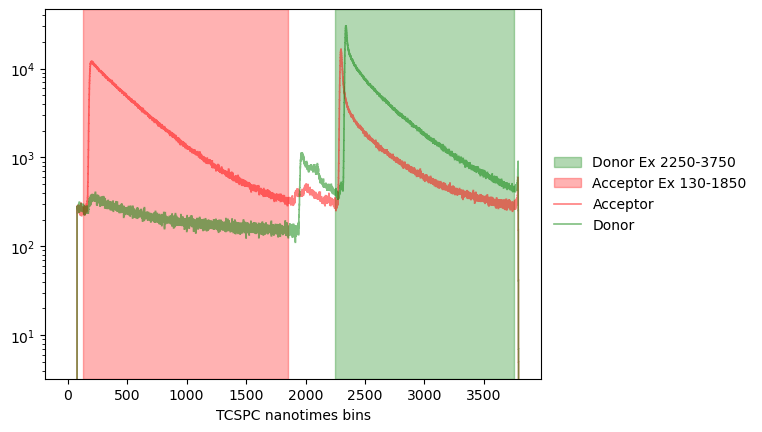

In [3]:
smf.plot.alternation_hist(raw)

Once you have ensured that all values are set and are correct, 
(if files converted to HDF5 correctly, you shouldn't have to set anything)
use the `smf.photonHDF5.normalize()` function to create a `PhotonData` object.

In [4]:
data = smf.photonHDF5.regularize_dets(raw)

> **Note**
>
> As we will see, smfBursts has 2 main types of objects:
> 1. Data
> 2. Instruction
>
> Data objects store the actual data, and `PhotonData` is the main type of data object.
> Instruction objects give instructions for how to process and compute values within data objects.
> 
> Next, we will see how to create these instructions, and give them to the `PhotonData` object to retrieve the values we are interested in.

## Defining Background

Before a burst search can be carried out, first the background must be estimated.
This estimation is typically done over a set of periods.

Therefore, to compute the background (so we can compute bursts later),
we must define instructions for how to
1. Divide the data-set into time periods
2. Compute the background

Defining periods is done simply by specifying the duration of the periods, and how to define the start and stop of the data.

Defining the background, we need to specify a fitting function, as well as a threshhold.

### The `Param` object

Instructions for dividing up periods is done by creating `smf.Param` objects.
To create them, there are 3 items that must be specified:
1. "tp"- the class on which the param is "based" (always a subclass of `smf.datamodel.tables.Table`),
   these classes contain the method for computing the underlying values
2. "params"- type-specific parameters, these are thresholds constants etc. defining the computation
3. "parents"- type-specific parents, these are other `smf.Param` objects that the current `smf.Param` relies on to provide values.

Creating a `smf.Param`, you simply call `smf.Param(<Table>, params=dict(<params>), parents=dict(<parents>))`
where the `dict(<params>)` and `dict(<parents>)` 

Lets see this done with the instrution for computing periods, and for computing background:

In [5]:
pr60 = smf.Param(smf.Periods, params=dict(detdef=data.detdef, period=60.0, 
                                          start_at='time_min', stop_at='over'))

bg60 = smf.Param(smf.BG, params=dict(func=smf.bg.exp_mlefit, 
                                     auto_threshold=True, tail_min=5e-4), 
                 parents=dict(base=pr60))

#### Periods

To define the periods, we use the `smf.Periods` class.
It has the following needed params:
- "detdef"- the number of each type of channel in the data (a `smf.DetDef` object, should be same as that of your `data` object)
- "period"- the duration of each period in seconds
- "start_at"- when the periods begin relative to the first photon in the data object.
  See the documentation for options, here we will use 'time_min'
- "stop_at"- when the periods end relative to the last photon in the data object.
  See the documentation for options, here we will use 'over'

These are packaged into a dictionary, and handed to `smf.Param`.
The parents of `smf.Param` always form a node in a directed graph.
Therefore, some `smf.Param` will have no parents, as starting nodes, 
`smf.Periods` is like this, it has no parents.

#### BG

To define the background, we use the `smf.BG` class.
It has the following params:
- "func"- the function used to compute the background, here we will use `smf.bg.exp_mlefit`,
  this function computes background by fitting the distribution of interphoton times,
  but the short times must be excluded, since these are a result of bursts.
  Thus the next two values are neeed:
- "tail_min"- the minimum time of interphoton times to incldue in analyzing the background, this is a time in seconds (float).
- "auto_threshold"- either `True` or `False`, if `False`, the computation is used with the specified threshold as-is,
  if it is `True`, then "tail_min" is used in an intial fit, which is then used to compute the ideal threshold to use,
  which is then used to compute the actual background.

We can check these three fields in the param by accessing the fields `bg60.tp`, `bg60.params` and `bg60.parents`

In [6]:
bg60.tp

smfbursts.backgroundtables.BG

In [7]:
bg60.params

(('compute_stream', 'single_all'),
 ('func',
  <function smfbursts.backgroundtables.exp_mlefit(times: numpy.ndarray[numpy.int64], clk_p: float, tail_min: float = 0.0005, auto_threshold: bool = False, F_bg: float = 2.0) -> float>),
 ('tail_min', array([0.0005, 0.0005, 0.0005, 0.0005, 0.0005])),
 ('auto_threshold', True),
 ('F_bg', 2.0))

In [8]:
bg60.parents

(('base',
  <class 'smfbursts.datamodel.tables.Param'>
  tp = <class 'smfbursts.backgroundtables.Periods'>
  params = (('period', 60.0), ('start_at', 'time_min'), ('stop_at',
      'over'), ('detdef', DetDef2ex2em at 0x73f3c980fcd0))
  parents = ()),)

**Note**

`smf.Param` objects can also be created more "elegantly" by specifying everything in the params and parents dictionarys as keyword arguments.
Additionally, some params may have default values (check documentation of `smf.datamodel.tables.Table` type to see), which can be omitted

In [9]:
pr30 = smf.Param(smf.Periods, detdef=data.detdef, period=30.0)
pr30.params

(('period', 30.0),
 ('start_at', 'time_min'),
 ('stop_at', 'over'),
 ('detdef', DetDef2ex2em at 0x73f3c980fcd0))

### The `Table` object

The `smf.Param` objects just created are *not* the actual computations,.
They are the *instructions* for how to compute the periods/background on a dataset.

To compute and examine the background, we need to give `prbg60` to `data`.


We can get the base `smf.datamodel.tables.Table` out of a `data` using the `smf.PhotonData.get_table()` method:

In [10]:
bg60tb = data.get_table(bg60)

`smf.datamodel.tables.Table` objects, as their name implies represent tables of values, with rows and columns.
Not all rows/columns are computed immediately, they instead must be "requested".

> **Note**
>
> The `smf.Param.tp` attribute is always the type of `Table` that is returned.

A given column can be retrieved from a table by indexing into it.
The columns available are table-type dependant.

For those of the type returned by `smf.bg.make_bg_param`, the primary row is
`['bg', <<ph_sel>>]` see below:

In [11]:
bg60tb['bg', smf.PhSel('0ex0em')]

array([636.08694555, 649.37420552, 646.37483591, 655.83446553,
       653.68345832, 657.4745802 , 649.35062722, 614.74876899,
       605.07345211, 605.63046762, 604.92513767, 567.89281363,
       593.93345027, 622.13142416, 634.7465552 , 630.16872945,
       645.61175731, 622.91246883, 602.67641604, 600.95775708,
       602.16838379, 569.24146935, 577.34247763, 572.09447182,
       577.82817344, 564.91539401, 576.78883402, 561.07838053,
       586.46596113, 596.29387675, 614.67749916, 599.81055128,
       613.25243216, 613.27672911, 638.43568159, 650.66181846,
       653.92263652, 660.48941177, 666.30834403, 670.87701661,
       661.35649402, 635.75613951, 608.75193792, 602.12440011,
       590.33861908, 599.56831412, 602.37443983, 631.55489531,
       637.9186314 , 649.53198947, 625.99281998, 619.03596728,
       594.13837967, 592.16911124, 580.40417426, 584.0507488 ,
       591.777038  , 598.50485328, 602.60879287, 602.69716211,
       591.72928985, 604.56994726, 579.32744238, 599.85

This is the background count rate for each time period. You are seeing a "column" of the table.

smfBursts identifies photon streams with `smf.PhSel` objects, which we will delve into deeper later.
But for now, understand that `smf.PhSel('0ex0em')` takes the string (`'0ex0em'`) and parses it into a stream definition.

This means the 0th excitation (ex), and 0th emmission channel (em) (ie Donor-Donor).

`smf.PhSel('0ex')` would specify all emmissions, but only from the 0th excitation (Donor-excitaiton-Donor-emission+Donor-excitation-Acceptor-emission).

### The `Column` object 

Now we can introduce `smf.Column` objects.
These are ways to specify a column in a `Table` and hand it around to all sorts of plotting and other functions.

To create a column object, you need 3 things:
1. `smf.Param` object
2. the column name
3. column keys

The column name is always the first thing specified in indexing into a `Table` object, so for the above example, it is `'bg'`.
The column keys are whatever comes afterwards, these are any additional definitions that should be included.
For `'bg'` columns, this is a `smf.Ph_sel`, because we need to know which photon stream we are looking at.

Below we create a column for the same column we accesed from the table before:

In [12]:
cbgDD60 = smf.Column(bg60, 'bg', (smf.PhSel('0ex0em'), ))

We can look at it's values with another `smf.PhotonData.get_...()` method: `smf.PhotonData.get_column()`.
This one you will likely use more often.

In [13]:
data.get_column(cbgDD60)

array([636.08694555, 649.37420552, 646.37483591, 655.83446553,
       653.68345832, 657.4745802 , 649.35062722, 614.74876899,
       605.07345211, 605.63046762, 604.92513767, 567.89281363,
       593.93345027, 622.13142416, 634.7465552 , 630.16872945,
       645.61175731, 622.91246883, 602.67641604, 600.95775708,
       602.16838379, 569.24146935, 577.34247763, 572.09447182,
       577.82817344, 564.91539401, 576.78883402, 561.07838053,
       586.46596113, 596.29387675, 614.67749916, 599.81055128,
       613.25243216, 613.27672911, 638.43568159, 650.66181846,
       653.92263652, 660.48941177, 666.30834403, 670.87701661,
       661.35649402, 635.75613951, 608.75193792, 602.12440011,
       590.33861908, 599.56831412, 602.37443983, 631.55489531,
       637.9186314 , 649.53198947, 625.99281998, 619.03596728,
       594.13837967, 592.16911124, 580.40417426, 584.0507488 ,
       591.777038  , 598.50485328, 602.60879287, 602.69716211,
       591.72928985, 604.56994726, 579.32744238, 599.85

Note that `data.get_column(cbgDD60)` returned the same values as `prbg60tb['bg', smf.Ph_sel('0ex0em')]`, because indeed, these two are equivalent.

> **Note**
> 
> It is generally preferable to use the 1-step `get_column()` instead of the multi-step `get_table()` then `table[col, ...]` style.

You often will also want to plot the data in columns in various ways.
smfBursts provides a number of convenience functions for plotting columns, which we will introduce periodically in this tutorial.

Below we have the `smf.plot.time_plot` and `smf.plot.time_scatter` functions, which take a `smf.PhotonData` and `smf.Column` object as input,
and plot the value on the y-axis and the time of the event.
These functions are wrappers for
[plt.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html#matplotlib.axes.Axes.plot) 
or 
[plt.scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html#matplotlib.axes.Axes.scatter) 
respectively, and asside from a few additional keyword arguments, pass all keyword arguments given to their respective matplotlib function.

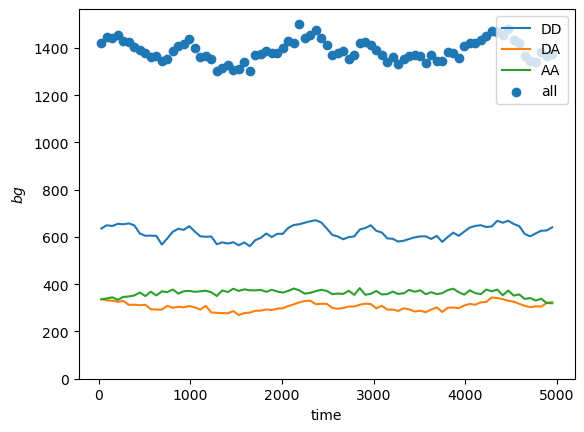

In [14]:
bgDD = smf.Column(bg60, 'bg', smf.PhSel('0ex0em'))
bgDA = smf.Column(bg60, 'bg', smf.PhSel('0ex1em'))
bgAA = smf.Column(bg60, 'bg', smf.PhSel('1ex1em'))
bgAll = smf.Column(bg60, 'bg', smf.PhSel('all'))

smf.plot.time_plot(data, bgDD, label='DD')
smf.plot.time_plot(data, bgDA, label='DA')
smf.plot.time_plot(data, bgAA, label='AA')
smf.plot.time_scatter(data, bgAll, label='all')
plt.ylim(0)
plt.legend()

## Burst Search

Now we can define how to conduct the burst search.

For this we use the `smf.Bursts` table-type.

> **Note**
>
> See [burst search](BurstSearchTutorial.ipynb) for a more complete description
> of how the burst search works
> (and more options for exactly how to conduct the burst search, although these are rarely used).
> The algorithm is also described in [Ingargiola 2016](https://doi.org/10.1371/journal.pone.0160716)
> Although the code has been further optimized and re-written in C

The common params are
- 'stream'- the photon stream on which to conduct the burst search
- 'm'- size of sliding window
- 'F'- the number of times above the background for a photon to be considered "in-burst"

And it has 1 parent:
- 'bg'- a `smf.BG` based `smf.Param` that defines the background count rate

In [15]:
bursts = smf.Param(smf.Bursts, m=10, F=6.0, stream=smf.PhSel('0ex_1ex1em'), bg=bg60)

The `smf.Param` object returned is a base burst search, which defines the bursts.
Bursts are fundamentally defined by start and stop times.
The rest of the parameters are in some way defined by the photons in the raw data between the start and stop times.

### Columns

The `bursts` param has many columns.
We will introduce columns progressively throughout this tutorial.

The first column that will be of interest is "nph_raw", like the "bg" column before, this column needs a `smf.PhSel` key to select which stream of photons it specifies.
This is the **raw** number of photons in the given stream.
It is **not** corrected for background or for cross-talk like leakage and direct excitation or differing detection efficies and laser powers ($\gamma$ and $beta$ factors).
(We will see how we can get those corrections from other columns later).

> **Note**
>
> Based on the multi-laboratory study of [Hellenkamp et. al.](https://doi.org/10.1038/s41592-018-0085-0)
> the "nph_raw" columns are equivalent to $^{i}I_{PhSel}$ parameters.

To visualize the different sizes of bursts, lets introduce another plotting function:
`smf.plot.scatter()` is a wrapper of matplotlib's 
[scatter()](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html#matplotlib.axes.Axes.scatter) function. 
Just give it the data, and 2 columsn to plot on the x and y axes respectively:

(-5.0, 200.0)

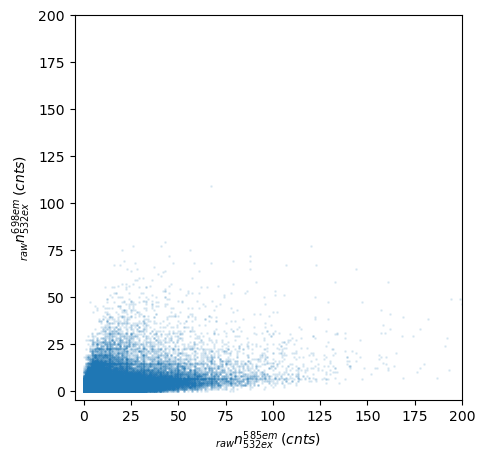

In [16]:
nphDD_raw = smf.Column(bursts, 'nph_raw', smf.PhSel('0ex0em'))
nphDA_raw = smf.Column(bursts, 'nph_raw', smf.PhSel('0ex1em'))

fig, ax = plt.subplots(figsize=(5,5))
smf.plot.scatter(data, nphDD_raw, nphDA_raw, 
                 s=1.0, alpha=0.1, include_unit=True, ax=ax)

ax.set_xlim([-5, 200])
ax.set_ylim([-5, 200])

### Gates

You will also notice that the minimum number of photons is quite low.
This is because the bursts have not been gated for total number of photons.
The burst-search uses a sliding window, which means that only a minimum of $m$ photons need been bunched together close enough to count as a burst.
Further, since the stream choosen to cover both the 0 and 1 (donor and acceptor) excitation that $m$ photons may be from any combination of the constituent channels.

Therefore it is customary to set a threshold for the minimum number of photons for which a burst must have in order for us to consider it.

This is done using `GateGroup` objects.
To only consider bursts with more than a certain value in a certain column, we use the `smf.make_geq_gate()` function (gte is short for greater than or equal to).

Simply define a column and threshold, and it creates the gate for you.

In [17]:
nphDDDAAA_raw = smf.Column(bursts, 'nph_raw', smf.PhSel('0ex_1ex1em'))
gateAll = smf.make_geq_gate(nphDDDAAA_raw, 50)

Now we can see the effect of applying the gate.
Here we introduce a new keyword argument that works with nearly all plotting functions in the `smf.plot` module: `gate`.
A gate supplied here will gate which values in the given colums(s) are included in the plot.

Here we will use some of the histogramming functions to get 1-D histograms.
These are `smf.plot.hist_bar()` and `smf.plot.hist_stair()` which histogram the specified column, gated with `gate` using
[np.histogram()](https://numpy.org/doc/stable/reference/generated/numpy.histogram.html)
and then pass the result to either
[ax.bar()](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html#matplotlib.axes.Axes.bar) 
or
[ax.stairs()](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.stairs.html#matplotlib.axes.Axes.stairs)
for `smf.plot.hist_bar()` and `smf.plot.hist_stair()` respectively.
Any keyword argument for the matplotlib functions can be passed to the smfBursts functions.

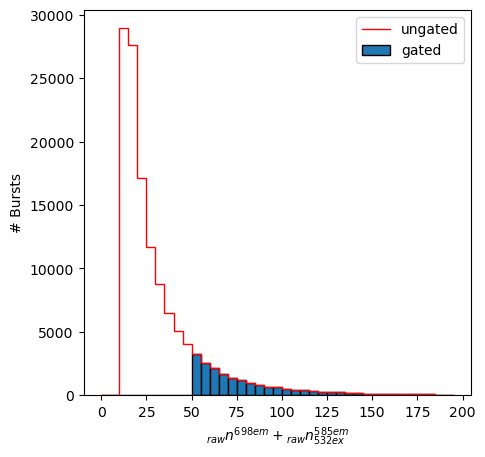

In [18]:
fig, ax = plt.subplots(figsize=(5,5))
bins = np.arange(0, 200, 5)
smf.plot.hist_bar(data, nphDDDAAA_raw, gate=gateAll,
                  label='gated', ax=ax, bins=bins, ec='k')
smf.plot.hist_stair(data, nphDDDAAA_raw, label='ungated', ax=ax, 
                    xlabel=False, ylabel=False, bins=bins, color='r')
# x/ylabel = False means x/ylabels of axes will not be set by this function call, 
# can also specify these as str to over-ride names given to x and y axes labels
ax.legend(markerscale=3);

Gates can be applied to both `smf.Param` and `smf.Column` objects using the `.regate()` method.
Columns created from a gated `smf.Param` maintain the gate of their `smf.Param`.
So creating a `smf.Column` from an ungated `smf.Param` and regating it is the same as creating a `smf.Column` from a `smf.Param` that has the final gate.

Further, when using `smf.PhotonData.get_column()`, the gate is applied, and so we can see how a `smf.Column` with a gate has fewer rows than without:

In [19]:
bursts_g = bursts.regate(gateAll)
nphDD_raw_g = nphDD_raw.regate(gateAll)
nphDD_raw_g_p = smf.Column(bursts_g, 'nph_raw', smf.PhSel('0ex0em'))
data.get_column(nphDD_raw).size, data.get_column(nphDD_raw_g).size, data.get_column(nphDD_raw_g_p).size

(128737, 19019, 19019)

#### `&` operator with gates

Another important feature of gates is that they can be combined together with the `&` operator.

The resulting gate will only include bursts that satisfy both gates used to create it.
This operation may also be compounded an arbitrary number of times.

> **Implementation Note**
>
> Compounding gates does have a limit based on the maximun number of dimensions in a numpy array.

(-5.0, 200.0)

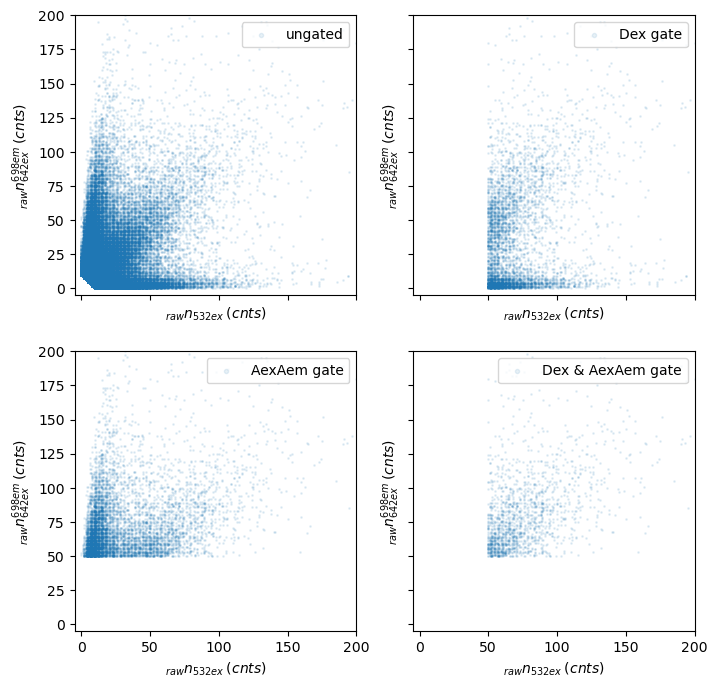

In [20]:
nphDDDA_raw = smf.Column(bursts, 'nph_raw', smf.PhSel('0ex'))
gateDDDA = smf.make_geq_gate(nphDDDA_raw, 50)
nphAA_raw = smf.Column(bursts, 'nph_raw', smf.PhSel('1ex1em'))
gateAA = smf.make_geq_gate(nphAA_raw, 50)

gateDDDA_AA = gateDDDA & gateAA

fig, ax = plt.subplots(2,2, figsize=(8,8), sharex=True, sharey=True)
smf.plot.scatter(data, nphDDDA_raw, nphAA_raw, s=1.0, alpha=0.1, 
                 include_unit=True, label='ungated', ax=ax[0,0])
smf.plot.scatter(data, nphDDDA_raw, nphAA_raw, gate=gateDDDA, s=1.0, alpha=0.1, 
                 include_unit=True, label='Dex gate', ax=ax[0,1])
smf.plot.scatter(data, nphDDDA_raw, nphAA_raw, gate=gateAA, s=1.0, alpha=0.1, 
                 include_unit=True, label='AexAem gate', ax=ax[1,0])
smf.plot.scatter(data, nphDDDA_raw, nphAA_raw, gate=gateDDDA_AA, s=1.0, alpha=0.1, 
                 include_unit=True, label='Dex & AexAem gate', ax=ax[1,1])
[axx.legend(markerscale=3, loc='upper right') for axx in ax.ravel()]
ax[0,0].set_xlim([-5, 200])
ax[0,0].set_ylim([-5, 200])

## Background Corrected Values

Usually when treating burst, we think of working with FRET efficiency and (if using ALEX/PIE) Stoichiometry.
In general these use background corrected intensities of photon counts by stream.

For this, we need to use `smf.NphBG`, which is `smf.datamodel.Table`, the param of which we create as below:

In [21]:
nphbg = smf.Param(smf.NphBG, base=bursts, bg=bg60)

We can access the background adjusted photon counts with the `"nph_bg"` column, which acts equivalently to `"nph_raw"`,
but we can see that it's values are always slightly *less* than `"nph_raw"` since backgrounds always subtracts photons.

> **Note**
>
> The `"nph_bg"` columns are equivalent to $^{ii}I_{PhSel} = ^{i}I_{PhSel} - I^{BG}_{Phsel}$
> from [Hellenkamp et. al.](https://doi.org/10.1038/s41592-018-0085-0)

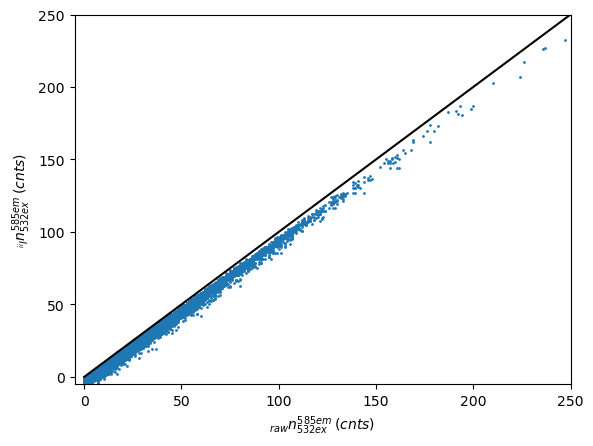

In [22]:
nphDD_bg = smf.Column(nphbg, 'nph_bg', smf.PhSel('0ex0em'))

fig, ax = plt.subplots()
smf.plot.scatter(data, nphDD_raw, nphDD_bg, s=1.0, ax=ax)
ax.set_xlim([-5,250])
ax.set_ylim([-5, 250])
ax.plot([0,250], [0,250], c='k')

In [23]:
data.get_table(nphbg)

In [24]:
data.get_column(nphDD_bg)

array([27.95333436, 39.28518863, 22.18517262, ..., -0.58672952,
       45.361149  , 15.52562234], shape=(128737,))

We can access the *uncorrected* FRET efficiency or Stoichiometry 
($^{ii}E_{app}$ and $^{ii}S_{app}$ respectively in [Hellenkamp et. al.](https://doi.org/10.1038/s41592-018-0085-0))
with the columns `"E_bg"` and `"S_bg"` (note that the columns do not take a `smf.PhSel` since those are baked into the column definition).

> **Note**
>
> `smf.plot.scatter()` does not set the axes limits.
> Without strict gating, background corrected bursts tend to have a few bursts where background correction results in negative intensities in some streams.
> For ratio based parameters, this results in values outside the $[0,1]$ range, somtimes significantly.
> Therefore it is usually best to set the x and y axis limits to some reasonable range slightly larger than $[0,1]$.
> Otherwise one axis may have a particularly large range hiding the patterns of reasonable bursts.

(-0.1, 1.1)

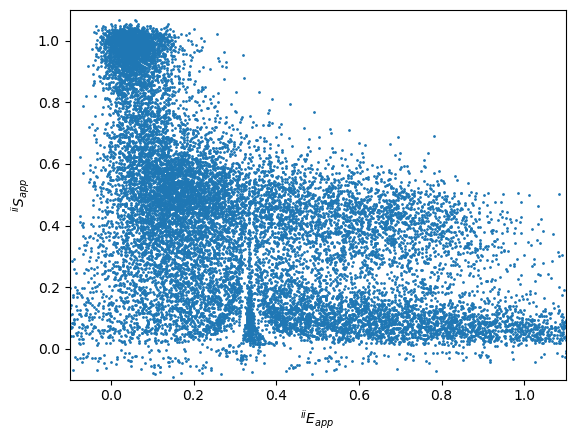

In [25]:
E_bg = smf.Column(nphbg, 'E_bg')
S_bg = smf.Column(nphbg, 'S_bg')

fig, ax = plt.subplots()
smf.plot.scatter(data, E_bg, S_bg, gate=gateAll, s=1.0, ax=ax)
ax.set_xlim([-0.1, 1.1])
ax.set_ylim([-0.1, 1.1])

> **Implementation Note**
>
> smfBrusts seeks to be as general as possible.
> Since E and S are particular ratios, they are actually implemented as "shortcuts" for the `"ratio_bg"` column.
> This column takes 2 `smf.PhSel` specifiers to define the numerator and denomonator of the ratio.
> So
>
> `smf.Column(nphbg, 'E_bg')`
>
> is equivalent to
>
> `smf.Column(nphbg, 'ratio_bg', (smf.PhSel('0ex1em'), smf.PhSel('0ex')))`
>
> and
>
> `smf.Column(nphbg, 'S_bg')`
> 
> is equivalent to
> 
> `smf.Column(nphbg, 'ratio_bg', (smf.PhSel('0ex'), smf.PhSel('0ex_1ex1em')))`

### `"E_raw"` and `"S_raw"`

While rarely used in the literature, fret ratios can also be computed from raw counts from `smf.Bursts` tables with the `"E_raw"` and `"S_raw"` columns ():

> **Implementation Note**
>
> Like in the previous note, `"E_raw"` and `"S_raw"` are aliases for
> 
> `smf.Column(bursts, "ratio_raw", (smf.PhSel('0ex1em'), smf.PhSel('0ex')))`
>
> and
>
> `smf.Column(bursts, "ratio_raw", (smf.PhSel('0ex'), smf.PhSel('0ex_1ex1em')))`

Text(0.5, 1.0, 'BG corrected ratios')

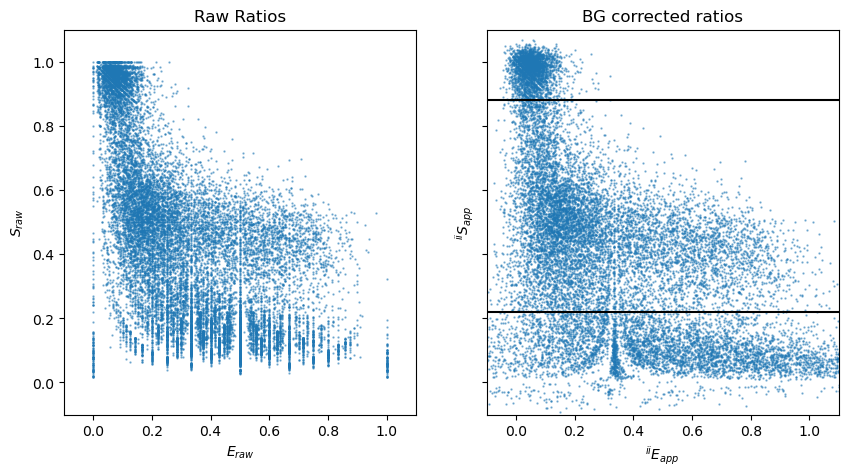

In [26]:
E_raw = smf.Column(bursts, 'E_raw')
S_raw = smf.Column(bursts, 'S_raw')

DO_thresh, AO_thresh = 0.88, 0.22

E_raw_g = E_raw.regate(gateAll)
S_raw_g = S_raw.regate(gateAll)

fig, ax = plt.subplots(1,2, figsize=(10,5), sharex=True, sharey=True)
smf.plot.scatter(data, E_raw_g, S_raw_g, s=0.5, alpha=0.5, ax=ax[0])
ax[0].set_title('Raw Ratios')
smf.plot.scatter(data, E_bg, S_bg, gate=gateAll, 
                 s=0.5, alpha=0.5, ax=ax[1])
ax[1].axhline(DO_thresh, c='k') # for threshold of DO, see next section
ax[1].axhline(AO_thresh, c='k') # for threshold of AO, see next section
ax[1].set_xlim([-0.1, 1.1])
ax[1].set_ylim([-0.1, 1.1])
ax[1].set_title('BG corrected ratios')

## Correction Factors

Now we can deal with FRET correction factors, to obtain *corrected* E and S values.
These are fundamentally about applying corrections to the observed intensities, 
for channel brightness and cross talk between channels.

Different formulations have been given for FRET correction factors.
The multilaboratory benchmark of [Hellenkamp et. al.](https://doi.org/10.1038/s41592-018-0085-0) is perhaps the most agreed-upon formulation.
Therefore smfBursts implements this standard, and we will follow the procedure from this paper.

Due to the history of FRETBursts with the Weiss lab, smfBursts also allows specification by the standard used by the Weiss lab
[Nir et. al. JPC B 2006](https://doi.org/10.1021/jp063483n), [Antonio Ingargiola]](https://doi.org/10.1101/083287).
The differences between the two are merely in name of parameters.

> **Note**
> Because smfBursts needs to handle more excitations, emissions, as well as polarization and split, 
> it combines all corrections factors into a generalized matrix representation.


### Spectral cross-talk

The first step is to determine the spectral cross-talk- the $\alpha$ (leakage) and $\delta$ (direct excitation) factors.

From the benchmark study [Hellenkamp et. al.](https://doi.org/10.1038/s41592-018-0085-0) we get the two following formulas for $\alpha$ and $\delta$:

$\alpha = \frac{\langle ^{ii}E^{DO}_{app}\rangle}{1-\langle ^{ii}E^{DO}_{app}\rangle}$

$\delta = \frac{\langle ^{ii}S^{AO}_{app}\rangle}{1-\langle ^{ii}S^{AO}_{app}\rangle}$

The super-prescript $ii$ indicates that all stream intensities ($I$) are corrected for background,
$DO$ super-post-script indicates Donor-only bursts, while $AO$ indicates Acceptor-only bursts, 
and the subscript $app$ inicates no correction factors have been applied (It is redundant with the $ii$.

$E = \frac{I_{Dex|Aem}}{I_{Dex|Dem}+I_{Dex|Aem}}$

$S = \frac{I_{Dex|Dem}+I_{Dex|Aem}}{I_{Dex|Dem}+I_{Dex|Aem}+}$

Therefore we must create gates to compute isolate the $DO$ and $AO$ populations of bursts.
This must be done with somewhat arbitrary thresholds.

Based on the apparent E/S scatter plots, we wil select the $DO$ gate as follows:
- $Dex\:photons\geq50$
- $S\geq0.88$

And for the $AO$
- $Aex\:photons\geq50$ 
- $S<0.22$

So we will make those gates, then retrieve the relevant, gated `"E_bg"` and `"S_bg"` columns, 
find their means and follow the formula for $\alpha$ and $\delta$:

In [27]:
# compute alpha (lk)
gate_DO = smf.make_geq_gate(S_bg, DO_thresh) & gateDDDA # make gate for DO
nphbgDO = nphbg.regate(gate_DO)
EDO_bg = smf.Column(nphbgDO, 'E_bg')
mean_EDO_bg = np.nanmean(data.get_column(EDO_bg))
alpha = mean_EDO_bg/(1-mean_EDO_bg)

# compute delta (dir_ex)
gate_AO = smf.make_lt_gate(S_bg, AO_thresh) & gateAA # make gate for AO
nphbgAO = nphbg.regate(gate_AO)
SAO_bg = smf.Column(nphbgAO, 'S_bg')
mean_SAO_bg = np.nanmean(data.get_column(SAO_bg))
delta = mean_SAO_bg/(1-mean_SAO_bg)
alpha, delta

(np.float64(0.05793459308872395), np.float64(0.07924919401884979))

### Cross-talk corrected values

At this point we need to compute the cross-talk corrected burst $E$ and $S$ values.
These are $^{iii}E$ and $^{iii}S$ in [Hellenkamp et. al.](https://doi.org/10.1038/s41592-018-0085-0).

smfBursts has a single Table type for all levels of correction beyond background: the `smf.Ratios` Table.
So we must create a cross-talk corrected Table with our $\alpha$ and $\delta$ values, using their names as parameters in creating the `smf.Param` object.
The param for background corrected stream values must be supplied to the `"nph"` kwarg:

In [28]:
ratios_ct = smf.Param(smf.Ratios, alpha=alpha, delta=delta, nph=nphbg)
ratios_ct_g = ratios_ct.regate(gateAll)

The `smf.Bursts` tables have equivalent columns to `smf.NphBG`.
For corrected intensities per stream, there is `"nph_c"` (equivalent to `"nph_bg"`).
FRET efficiency and Stoichiometry are `"E"` and `"S"`.

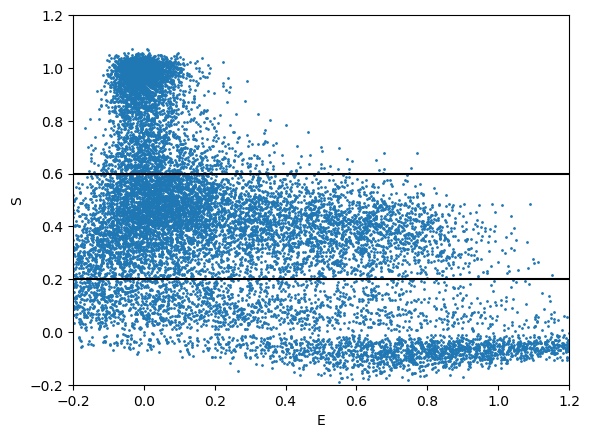

In [29]:
E_ct_g = smf.Column(ratios_ct_g, "E")
S_ct_g = smf.Column(ratios_ct_g, "S")

FA_thresh_h, FA_thresh_l = 0.6, 0.2


fig, ax = plt.subplots()
smf.plot.scatter(data, E_ct_g, S_ct_g, s=1.0, ax=ax)
ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2])
ax.axhline(FA_thresh_h, c='k')
ax.axhline(FA_thresh_l, c='k')

### Cross-Section corrected Values

Next we need to calculate the $\gamma$ and $\beta$ values.

These are computed by fitting the equation

$^{iii}S_{app}^{(DA)} = (1+\gamma\beta+(1-\gamma)\beta(^{iii}E_{app}^{(DA)})))^{-1}$

Where $DA$ indicates bursts that hvae both a donor and acceptor active.
Therefore we need to define a gate that isolates the $DA$ population, and do a least squares minimization of the $E$ and $S$ values of bursts corrected for cross-talk to the above equation.

In [30]:
from scipy.optimize import minimize
from scipy.stats import linregress

def gamma_beta(x, E, S):
    gamma, beta = x
    diff =  1/(1+gamma*beta+(1-gamma)*beta*E) - S
    return np.sum(diff**2)

In [31]:
nphctDDDAAA = smf.Column(ratios_ct, 'nph_c', smf.PhSel('0ex_1ex1em'))
nphctDDDA = smf.Column(ratios_ct, 'nph_c', smf.PhSel('0ex'))
nphctAA = smf.Column(ratios_ct, 'nph_c', smf.PhSel('1ex1em'))
gate_ct_All = smf.make_geq_gate(nphctDDDAAA, 50)
gate_ct_FA = smf.make_geq_gate(nphctDDDA, 30) & smf.make_geq_gate(nphctAA, 30)

gamma:0.7968966563799201, beta:1.4691961555423434, <S cross talk corrected>0.4482811245061889


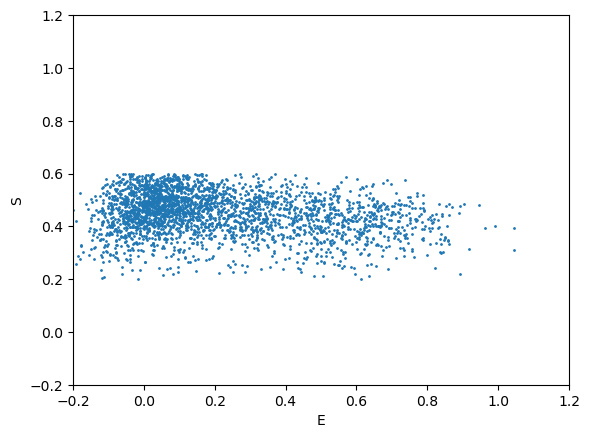

In [32]:
gate_FRET = smf.make_range_gate(S_ct_g, FA_thresh_l, FA_thresh_h) & gate_ct_FA
fig, ax = plt.subplots()
smf.plot.scatter(data, E_ct_g, S_ct_g, gate=gate_FRET, s=1.0, ax=ax)
ax.set_xlim([-0.2, 1.2])
ax.set_ylim([-0.2, 1.2])

eFRET = data.get_column(E_ct_g.regate(gate_FRET))
sFRET = data.get_column(S_ct_g.regate(gate_FRET))

gbresult = minimize(gamma_beta, (1.0, 1.0), args=(eFRET, sFRET))
gamma, beta = gbresult.x
gamma, beta

print(f'gamma:{gamma}, beta:{beta}, <S cross talk corrected>{np.mean(data.get_column(S_ct_g.regate(gate_FRET)))}')

Now we can build a fully corrected bursts object with $\alpha$, $\delta$, $\gamma$ and $\beta$ defined:

In [33]:
ratioc = smf.Param(smf.Ratios, alpha=alpha, delta=delta, 
                   gamma=gamma, beta=beta, nph=nphbg)

nphcDDDAAA = smf.Column(ratioc, 'nph_c', smf.PhSel('0ex_1ex1em'))
nphcDDDA = smf.Column(ratioc, 'nph_c', smf.PhSel('0ex'))
nphcDD = smf.Column(ratioc, 'nph_c', smf.PhSel('0ex0em'))
nphcDA = smf.Column(ratioc, 'nph_c', smf.PhSel('0ex1em'))
nphcAA = smf.Column(ratioc, 'nph_c', smf.PhSel('1ex1em'))
Ec = smf.Column(ratioc, 'E')
Sc = smf.Column(ratioc, 'S')

<S corrected> = 0.4989859085111638


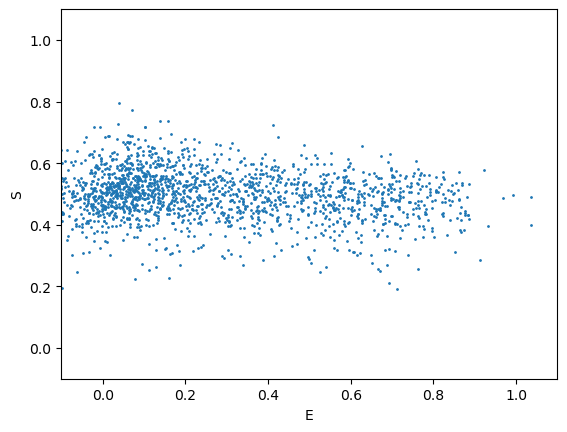

In [34]:
gatec_All = smf.make_geq_gate(nphcDDDAAA, 50)
gatec_DA = gatec_All & smf.make_geq_gate(nphcDDDA, 30)
gatec_FA = smf.make_geq_gate(nphcDDDA, 30) & smf.make_geq_gate(nphcAA, 30)
gatec_FRET = smf.make_range_gate(Sc, 0.3, 0.7) & gatec_FA

fig, ax = plt.subplots()
smf.plot.scatter(data, Ec, Sc, gate=gatec_FA, s=1.0)
ax.set_xlim([-0.1, 1.1])
ax.set_ylim([-0.1, 1.1])
print(f'<S corrected> = {np.mean(data.get_column(Sc.regate(gatec_FRET)))}')

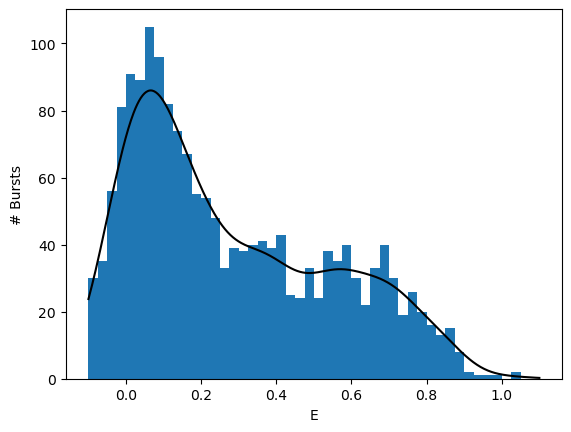

In [35]:
smf.plot.hist_kdeoverlay(data, Ec, gate=gatec_FA, bins=np.linspace(-0.1, 1.1, 49), 
                         kdeplot_kwargs={'c':'k'});

## Output for publications

smfBursts is designed to work easily with publication.


### Object Descriptions

Therefore all Param, Column and Gate objects have a `.description` attribute, which creates a [YAML](https://yaml.org/)-like string that describes the object.
This is ideal for supplementary material- simply print the `.description` string, and copy into the supplementary.
It is often too long to include in main text, especially if a gate is involved that is made of multiple gates.
However, simply from the raw data nd the description, it is feasible to redo the analysis.

In [36]:
print(ratioc.description)

Table: Ratios
Params:
  corr_mat: [[ 0.79689666  0.          0.          0.        ]
             [-0.04616788  1.          0.         -0.07924919]
             [ 0.          0.          1.          0.        ]
             [ 0.          0.          0.          0.68064431]]
Parents:
  nph:
    Table: NphBG
    Params:
      single: True
    Parents:
      base:
        Table: Bursts
        Params:
          func: smfbursts.bursttables.burstsearch_mwindowF_bg
          stream: 0ex_1em
          m: 10
          F: 6.0
          c: -1.0
          fuse: 0.0
        Parents:
          bg:
            Table: BG
            Params:
              compute_stream: single_all
              func: smfbursts.backgroundtables.exp_mlefit
              tail_min: [0.0005 0.0005 0.0005 0.0005 0.0005]
              auto_threshold: True
              F_bg: 2.0
            Parents:
              base:
                Table: Periods
                Params:
                  period: 60.0
                  st

Note that oftentimes, the majority of the important information is available in the "Params" section of the description.

### Getting citations

Another useful feature is the `smf.get_citations()` function.

As you run smfBursts, it keeps track of which methods have been used, and adds the relevant citations to a running list.

To get a list of citations that should be included in your paper based on the analysis you have run at any point in your script, you can simply run `smf.get_citation()`.
This returns a list of strings, each string is a citation, by default in the Nature citation format.

Below is an example, wrapped in a `for` loop with print statements so that the output looks like a bibliography.

> **Note**
>
> The `smf.get_citations()` method is only a helper method.
> It should be viewd as the minimum number of methods papers that should be cited.

In [37]:
for i, c in enumerate(smf.get_citations()):
    print(f'{i+1}. {c}\n')

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X. FRETBursts: An open source toolkit for analysis of freely-diffusing Single-molecule FRET. PLoS ONE 11, 1–27 (2016).

2. Müller, B. K., Zaychikov, E., Bräuchle, C. & Lamb, D. C. Pulsed interleaved excitation. Biophysical Journal 89, 3508–3522 (2005).

3. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison between theory and experiments. Journal of Physical Chemistry B 110, 22103–22124 (2006).

4. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M. Monitoring conformational dynamics of a single molecule by selective fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561 (1998).

5. Hellenkamp, B., Schmid, S., Doroshenko, O. et al. Precision and accuracy of single-molecule FRET measurements—a multi-laboratory benchmark study. Nat Methods 15, 669–676 (2018).



You can also use the `style` keyword argument to get either bibtex or RIS style citations, 
which makes adding the citations to your bibliographic reference program easier.

Do this by specifying `smf.get_citations(style='bibtex')` or `smf.get_citations(style='ris')` for bibtex or RIS respectively:

In [38]:
for c in smf.get_citations(style='bibtex'):
    print(c)

@article{IngargiolaPLOSOne2016,
 author = {Ingargiola, Antonino and Lerner, Eitan and Chung, SangYoon and Weiss, Shimon and Michalet, Xavier},
 doi = {10.1371/journal.pone.0160716},
 journal = {PLOS ONE},
 keywords = {},
 note = {https://journals.plos.org/plosone/article/file?id=10.1371/journal.pone.0160716&type=printable},
 number = {8},
 pages = {e0160716},
 title = {FRETBursts: An Open Source Toolkit for Analysis of Freely-Diffusing Single-Molecule FRET},
 url = {https://app.dimensions.ai/details/publication/pub.1051038002},
 volume = {11},
 year = {2016}
}

@article{MullerBiophysJ2005,
	title = {Pulsed interleaved excitation},
	volume = {89},
	issn = {00063495},
	doi = {10.1529/biophysj.105.064766},
	number = {5},
	journal = {Biophysical Journal},
	author = {Müller, Barbara K. and Zaychikov, Evgeny and Bräuchle, Christoph and Lamb, Don C.},
	year = {2005},
	note = {ISBN: 4989218077560},
	pages = {3508--3522},,
}

@article{NirJPCB2006,
 title = {Shot-noise limited single-molecule {F

In [39]:
for c in smf.get_citations(style='ris'):
    print(c)

TY  - JOUR
AN  - pub.1051038002
TI  - FRETBursts: An Open Source Toolkit for Analysis of Freely-Diffusing Single-Molecule FRET
AU  - Ingargiola, Antonino
AU  - Lerner, Eitan
AU  - Chung, SangYoon
AU  - Weiss, Shimon
AU  - Michalet, Xavier
PY  - 2016
JO  - PLOS ONE
VL  - 11
IS  - 8
SP  - e0160716
DO  - 10.1371/journal.pone.0160716
UR  - https://app.dimensions.ai/details/publication/pub.1051038002
L2  - https://journals.plos.org/plosone/article/file?id=10.1371/journal.pone.0160716&type=printable
U1  - 27532626 [PMID]
U1  - PMC4988647 [PMCID]
Y2  - 2025/10/21
ER  -
TY  - JOUR
TI  - Pulsed interleaved excitation
AU  - Müller, Barbara K.
AU  - Zaychikov, Evgeny
AU  - Bräuchle, Christoph
AU  - Lamb, Don C.
T2  - Biophysical Journal
DA  - 2005///
PY  - 2005
DO  - 10.1529/biophysj.105.064766
VL  - 89
IS  - 5
SP  - 3508
EP  - 3522
SN  - 00063495
ER  -
TY  - JOUR
TI  - Shot-noise limited single-molecule FRET histograms: Comparison between theory and experiments
AU  - Nir, Eyal
AU  - Michalet, Xa

`smf.get_citations()` also has the `include_purpose` keyword argument.
If this is `include_purpose=True`, then it returns a list of 2-tuples.
The first element of the 2-tuple is the citation string, (in the selected format),
and the second element is another tuple, this time of strings describing why the citation should be included:

In [40]:
for i, (cit, purps) in enumerate(smf.get_citations(include_purpose=True)):
    print(f'{i+1}. {cit}')
    for p in purps:
        print(f'    {p}') # so each purpose is indented on new line

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X. FRETBursts: An open source toolkit for analysis of freely-diffusing Single-molecule FRET. PLoS ONE 11, 1–27 (2016).
    smfBursts citation
    background analysis with smfBursts
2. Müller, B. K., Zaychikov, E., Bräuchle, C. & Lamb, D. C. Pulsed interleaved excitation. Biophysical Journal 89, 3508–3522 (2005).
    using PIE/nsALEX
3. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison between theory and experiments. Journal of Physical Chemistry B 110, 22103–22124 (2006).
    Dual Channel Burst Search
4. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M. Monitoring conformational dynamics of a single molecule by selective fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561 (1998).
    sliding window burst search
5. Hellenkamp, B., Schmid, S., Doroshenko, O. et al. Precision and accuracy of single-molecule FRET measurements—a multi-laboratory benchmark stu

For quick display of the currently recomended citations, there is also the `print_citations()` function.

This will print out the citations with numbered headers, and wrapped and indented so that it is easily readable:

> **Note**
>
> The length of the lines can be changed with the `linesize` keyword argument.
> You can also have the function return the string it printed with the `return_string` keyword argument.

In [41]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Müller, B. K., Zaychikov, E., Bräuchle, C. & Lamb, D. C. Pulsed interleaved
    excitation. Biophysical Journal 89, 3508–3522 (2005).
3. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison
    between theory and experiments. Journal of Physical Chemistry B 110,
    22103–22124 (2006).
4. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
5. Hellenkamp, B., Schmid, S., Doroshenko, O. et al. Precision and accuracy of
    single-molecule FRET measurements—a multi-laboratory benchmark study. Nat
    Methods 15, 669–676 (2018).


## BVA

smfBursts also provides an implementation of [BVA](https://doi.org/10.1016/j.bpj.2011.01.066), as a column of `smf.Bursts`.

The variance of a given burst is defined as

$$\sigma_{i} = \sqrt{\frac{1}{M_{i}}\sum_{j=1}^{M_{i}}{\epsilon_{i,j}-\mu_{i}}})$$

Where $i$ is an index for a particular burst, $\mu_{i} = N_{i}/D_{i}$ where $N_{i}$ is the number of photons in stream A in burst $i$, and $D_{i}$ is the number of photons in stream B.
Stream B must include stream A. Effectively B is all photons in the burst for the parameter of interest.
$\epsilon_{ij}$ is similar to $\mu_{i}$, being a ratio, but here the burst is divided into $M$ consecutive intervals such that there are a total of $N$ photons of stream B in each interval.

In the original classification, stream A is (DexAem, ) ie `smf.PhSel('0ex1em')`, and stream B is (DexDem, DexAem), ie `smf.PhSel('0ex')`.

The BVA column is specified with the column name `"bva"` and additional keys of \[stream A, stream B, N\] as below:

In [42]:
bva10 = smf.Column(bursts, 'bva', (smf.PhSel('0ex1em'), smf.PhSel('0ex'), 10))

Below is a standard BVA of FRET efficiency plotted against E, with the static heterogenity semicircle plotted:

> **Note**
>
> In the example below, the uncorrecte "E_raw" column is used.
> This is because the static-heterogeneity semi-circle is based on assuming no correction factors or background.

(-0.05, 1.01)

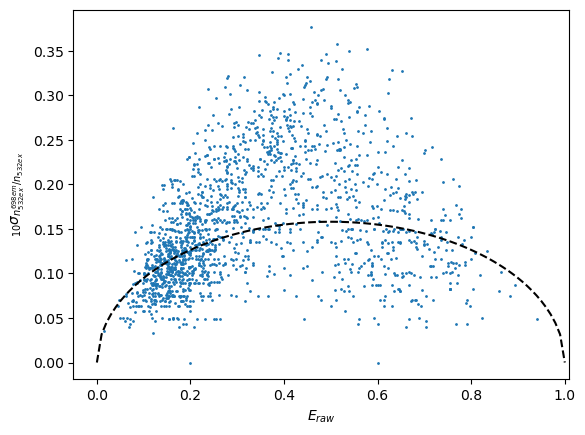

In [43]:
smf.plot.scatter(data, E_raw, bva10, gate=gatec_FRET, s=1.0)
x = np.linspace(0,1,100)
y = np.sqrt(x*(1-x)/10)
plt.plot(x, y, ls='--', c='k')
plt.xlim([-0.05, 1.01])

Using 5 for $N$:

(-0.05, 1.01)

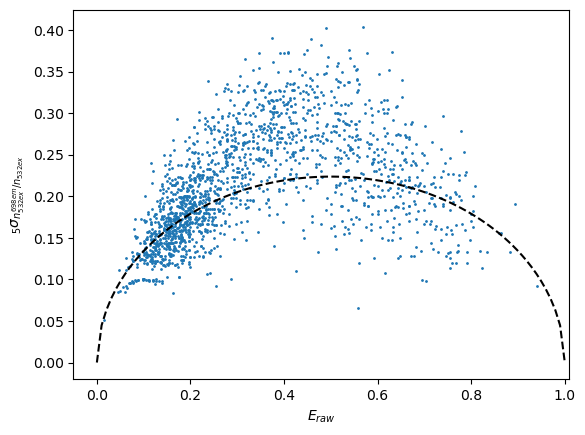

In [44]:
bva5 = smf.Column(bursts, 'bva', (smf.PhSel('0ex1em'), smf.PhSel('0ex'), 5))
smf.plot.scatter(data, E_raw, bva5, gate=gatec_FRET, s=1.0)
x = np.linspace(0,1,100)
y = np.sqrt(x*(1-x)/5)
plt.plot(x, y, ls='--', c='k')
plt.xlim([-0.05, 1.01])

Looking for variation in Stoichiometry (unusual as that may be) would look like this:

(-0.05, 1.01)

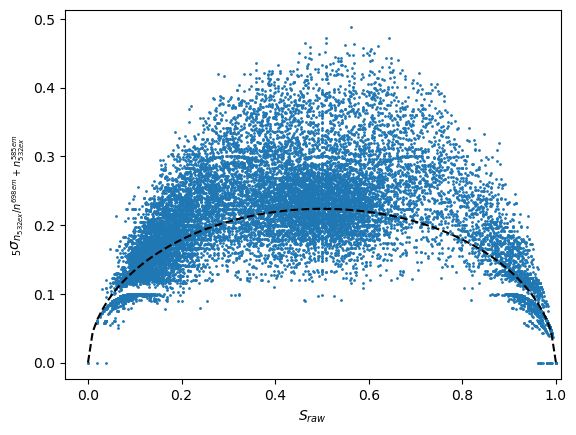

In [45]:
bvaS5 = smf.Column(bursts, 'bva', (smf.PhSel('0ex'), smf.PhSel('0ex_1ex1em'), 5))
smf.plot.scatter(data, S_raw, bvaS5, gate=gateAll, s=1.0)
x = np.linspace(0,1,100)
y = np.sqrt(x*(1-x)/5)
plt.plot(x, y, ls='--', c='k')
plt.xlim([-0.05, 1.01])

## Burst Separation

The spacing between bursts is useful for several reasons.
First a quality control check to ensure the concentration of labeled molecules is low enough to ensure that two molecules being present in the confocal volume at once is sufficiently small.
(A general rule of thumb is that the mode of the distribution should be ~1s)

Second, it can be used in recurrence analysis of single particles [(RASP)](https://doi.org/10.1039/C0CP01911A) to assess data for indication of conformational dynamics.

### Non-Atomic columns

The column `"sep"` is used to access the time separation betweeen bursts.
All columns discussed before burst separattion have values that are "internal" to the burst.
They are are unaffected (in terms of computation) by neighboring bursts.
However, the separation depends on the end time of one burst and the start time of the next.
Therefore, if bursts are removed, then the "next" burst may be different, thus changeing the separation.
Additionally, there are only $n-1$ separations between bursts if $n$ is the number of bursts.

> **Attention**
> 
> smfBursts distinguishes between **atomic** and **non-atomic** columns
> - **Atomic** columns values are independant of the gate used, this is the case for most columns
> - **Non-Atomic** columns have values that change depending on the gate

smfBursts deals with having valued dependant on which bursts are inlcuded by making the values dependant on the gate of the Param used to create the column.

And with the issue of having $n-1$ values by defining an "offset". 
The offset can be 0 or 1, and defines where the column "starts" relative to columns.
If the offset is 0, then the last element of the array returned by `get_column()` will have the fill value of `NAN`.
If the offset is 1, then the first element of the array has the `NAN` fill value.
So in essence, if the offset is 0 then the column looks at the separation between the current burst and the next burst (the forward separation).
Whie if the offset is 1, the column looks at the separtion between the previous burst and the current one (the backward separation).

As show below, two otherwise identical `"sep"` columns where the input param is regated in 1 to a stricter gate,
the results are dramatically different, with the stricter gate having fewer bursts, and also much longer separations.

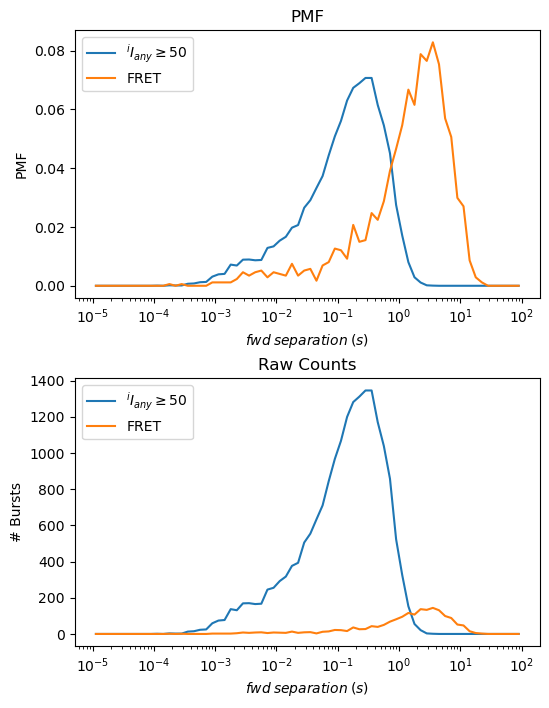

In [46]:
sep_gf = smf.Column(bursts_g, 'sep', offset=0)
sep_FRETf = smf.Column(bursts_g.regate(gatec_FRET), 'sep', offset=0)

fig, ax = plt.subplots(2, figsize=(6,8), gridspec_kw={'hspace':0.3})
smf.plot.hist_line(data, sep_gf, bins=np.logspace(-5,2, 71), ax=ax[0], 
                   label=r'$^{i}I_{any}\geq 50$', xlabel=False, normalize='PMF')
smf.plot.hist_line(data, sep_FRETf, bins=np.logspace(-5,2, 71), ax=ax[0], 
                   label='FRET', include_unit=True, normalize='PMF')

ax[0].set_xscale('log')
ax[0].set_title("PMF")
ax[0].legend(loc='upper left')

smf.plot.hist_line(data, sep_gf, bins=np.logspace(-5,2, 71), ax=ax[1], 
                   label=r'$^{i}I_{any}\geq 50$', xlabel=False)
smf.plot.hist_line(data, sep_FRETf, bins=np.logspace(-5,2, 71), ax=ax[1], 
                   label='FRET', include_unit=True)

ax[1].set_xscale('log')
ax[1].set_title("Raw Counts")
ax[1].legend(loc='upper left')

### Recurrence Analysis of Single Particles (RASP)

Non-Atomic columns can still be used to create gates.

Let's see how to use gates based on burst separation to perform [RASP](https://doi.org/10.1039/C0CP01911A).

We can find bursts with a subsequent burst within some time using a `sep` column with a 0 offset with a less than gate.
If the column in the less than gate has an offset of 1 instead, then the gate finds bursts with a previous burst within the time.

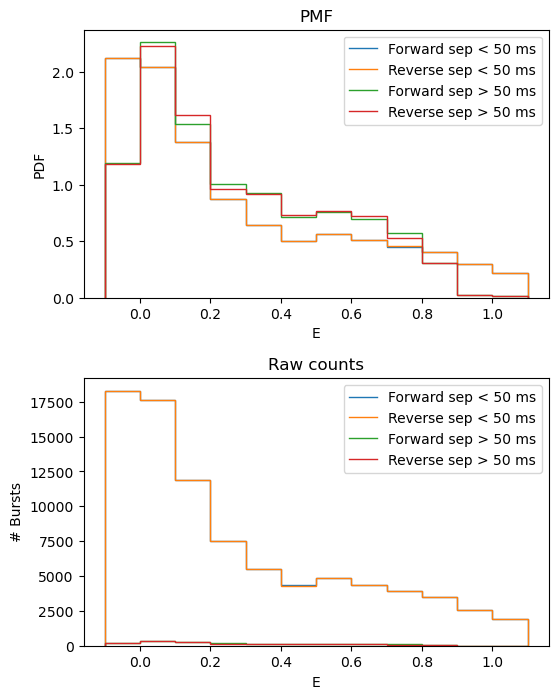

In [47]:
sep_FRETr = smf.Column(bursts_g.regate(gatec_FRET), 'sep', offset=1)

# create gates for all combinations of < / >= and short/long burst separation
gate_le_sepf = smf.make_lt_gate(sep_FRETf, 5e-2)
gate_le_sepr = smf.make_lt_gate(sep_FRETr, 5e-2)
gate_geq_sepf = smf.make_geq_gate(sep_FRETf, 5e-2)
gate_geq_sepr = smf.make_geq_gate(sep_FRETr, 5e-2)

fig, ax = plt.subplots(2, figsize=(6,8), gridspec_kw={'hspace':0.3})

bins = np.linspace(-0.1, 1.1, 13)
smf.plot.hist_stair(data, Ec, gate=gate_le_sepf, ax=ax[0], 
                    label="Forward sep < 50 ms", normalize='PDF', bins=bins)
smf.plot.hist_stair(data, Ec, gate=gate_le_sepr, ax=ax[0], 
                    label="Reverse sep < 50 ms", normalize='PDF', bins=bins)
smf.plot.hist_stair(data, Ec, gate=gate_geq_sepf, ax=ax[0], 
                    label="Forward sep > 50 ms", normalize='PDF', bins=bins)
smf.plot.hist_stair(data, Ec, gate=gate_geq_sepr, ax=ax[0], 
                    label="Reverse sep > 50 ms", normalize='PDF', bins=bins)
ax[0].set_title("PMF")
ax[0].legend()
smf.plot.hist_stair(data, Ec, gate=gate_le_sepf, ax=ax[1], 
                    label="Forward sep < 50 ms", bins=bins)
smf.plot.hist_stair(data, Ec, gate=gate_le_sepr, ax=ax[1], 
                    label="Reverse sep < 50 ms", bins=bins)
smf.plot.hist_stair(data, Ec, gate=gate_geq_sepf, ax=ax[1], 
                    label="Forward sep > 50 ms", bins=bins)
smf.plot.hist_stair(data, Ec, gate=gate_geq_sepr, ax=ax[1], 
                    label="Reverse sep > 50 ms", bins=bins)
ax[1].set_title("Raw counts")
ax[1].legend()

#### `|` Gates

To isolate bursts that are "recurrent" or "non-recurrent" bursts, it would be ideal to create gates that combine forward and backward separations.
This is possible using the `|` (OR) operation on the previously created gates.

The OR operation does as the name implies.
If a burst is in either of the input gates, the burst is in the output gate.

> **Caution**
>
> Remember that the OR operation applies to the entirety of both gates used.
> Therefore if one gate does not have any size threshold, all bursts, even those with small counts can get included, even when the other gate contains an approrpiate threshold.


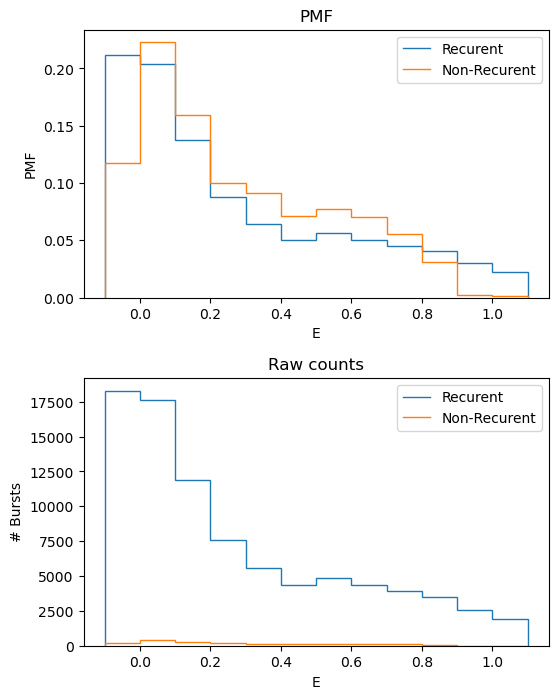

In [48]:
gate_recur = gate_le_sepf | gate_le_sepr
gate_nonrecur = gate_geq_sepf | gate_geq_sepr

bins = np.linspace(-0.1, 1.1, 13)

# Make plots
fig, ax = plt.subplots(2, figsize=(6,8), gridspec_kw={'hspace':0.3})
# Plot for upper PMF histograms
smf.plot.hist_stair(data, Ec, gate=gate_recur, label='Recurent', 
                    ax=ax[0], bins=bins, normalize='PMF')
smf.plot.hist_stair(data, Ec, gate=gate_nonrecur, label="Non-Recurent", 
                    ax=ax[0], bins=bins, normalize='PMF')
ax[0].set_title("PMF")
ax[0].legend()
# Plot for raw counts histograms
smf.plot.hist_stair(data, Ec, gate=gate_recur, label='Recurent', 
                    ax=ax[1], bins=bins)
smf.plot.hist_stair(data, Ec, gate=gate_nonrecur, label="Non-Recurent", 
                    ax=ax[1], bins=bins)
ax[1].set_title("Raw counts")
ax[1].legend()

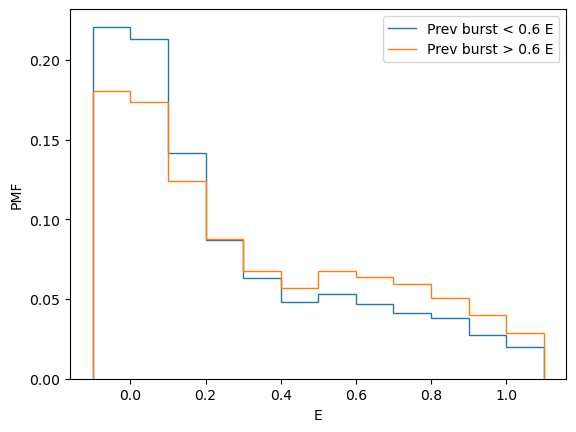

In [49]:
F_split = 0.6
gate_lt_sep_E_lt = gate_le_sepf&smf.make_lt_gate(Ec, F_split)
gate_lt_sep_E_geq = gate_le_sepf&smf.make_geq_gate(Ec, F_split)
rasplf = smf.GateGroup.as_gategroup(smf.MappedGate(smf.gates.SHIFT_mapgate, 
                                                   {'offset':1, 'fill':False}, 
                                                   gate_recur, gate_lt_sep_E_lt))
rasphf = smf.GateGroup.as_gategroup(smf.MappedGate(smf.gates.SHIFT_mapgate, 
                                                   {'offset':1, 'fill':False}, 
                                                   gate_recur, gate_lt_sep_E_geq))

fig, ax = plt.subplots()
smf.plot.hist_stair(data, Ec, gate=rasplf, label=f'Prev burst < {F_split} E', 
                    ax=ax, bins=bins, normalize='PMF')
smf.plot.hist_stair(data, Ec, gate=rasphf, label=f'Prev burst > {F_split} E', 
                    ax=ax, bins=bins, normalize='PMF')
ax.legend()

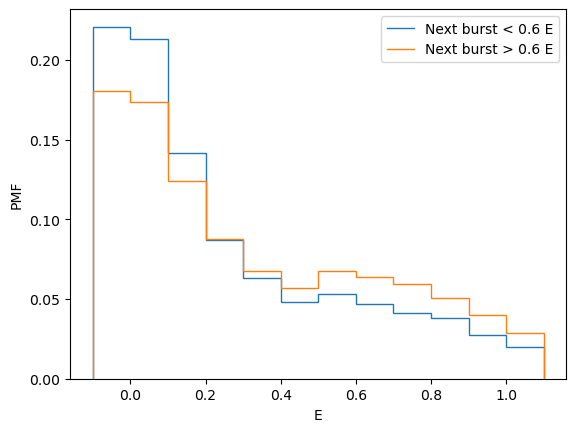

In [50]:
F_split = 0.6
gate_lt_sep_E_lt = gate_le_sepr&smf.make_lt_gate(Ec, F_split)
gate_lt_sep_E_geq = gate_le_sepr&smf.make_geq_gate(Ec, F_split)
rasplfr = smf.GateGroup.as_gategroup(smf.MappedGate(smf.gates.SHIFT_mapgate, 
                                                    {'offset':-1, 'fill':False}, 
                                                    gate_recur, gate_lt_sep_E_lt))
rasphfr = smf.GateGroup.as_gategroup(smf.MappedGate(smf.gates.SHIFT_mapgate, 
                                                    {'offset':-1, 'fill':False}, 
                                                    gate_recur, gate_lt_sep_E_geq))

fig, ax = plt.subplots()
smf.plot.hist_stair(data, Ec, gate=rasplfr, label=f'Next burst < {F_split} E', 
                    ax=ax, bins=bins, normalize='PMF')
smf.plot.hist_stair(data, Ec, gate=rasphfr, label=f'Next burst > {F_split} E', 
                    ax=ax, bins=bins, normalize='PMF')
ax.legend()

(-0.1, 1.1)

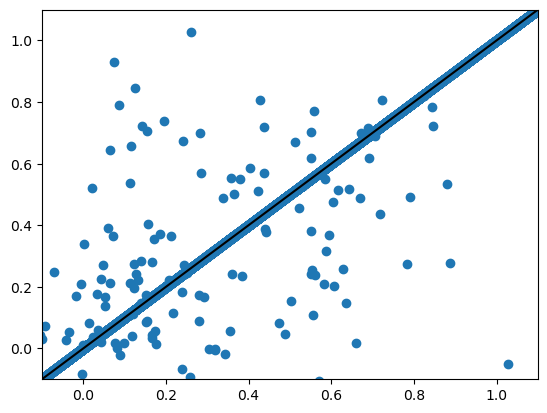

In [51]:
plt.scatter(data.get_column(Ec.regate(gate_le_sepf)), 
            data.get_column(Ec.regate(gate_le_sepr)))

plt.plot([-0.1, 1.1], [-0.1, 1.1], c='k')
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])

## Lifetime Based Columns

smfBursts also supports some methods of lifetime based analyis.

2 columns are implemented for this: `nanohist` and `nanomean`.

### Nanotime histograms

The `smf.Bursts` table has a column `nanohist` which retrieves the TCSPC (nanotime) histogram for each burst.
The `nanohist` column needs one key, the photon stream to select.

Note that calling `data.get_column(nh)` returns a *2D* array- each row is a burst, and each column a tcspc bin.
That is the return is indexed `[burst, tcspc_bin]`.

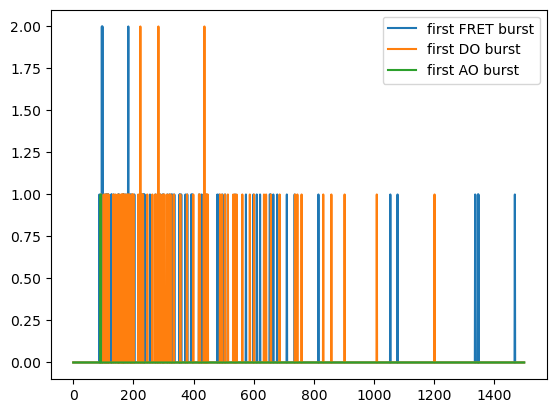

In [52]:
nh = smf.Column(bursts, 'nanohist', smf.PhSel('0ex0em'))
nh_fret = nh.regate(gatec_FRET)
nh_DO = nh.regate(gate_DO)
nh_AO = nh.regate(gate_AO)

plt.plot(data.get_column(nh_fret)[0,:], label='first FRET burst')
plt.plot(data.get_column(nh_DO)[0,:], label='first DO burst')
plt.plot(data.get_column(nh_AO)[0,:], label='first AO burst')
plt.legend()

We can use this to get the tcspc decay of a whole subpopulation, by summing over the starting (0) axis:

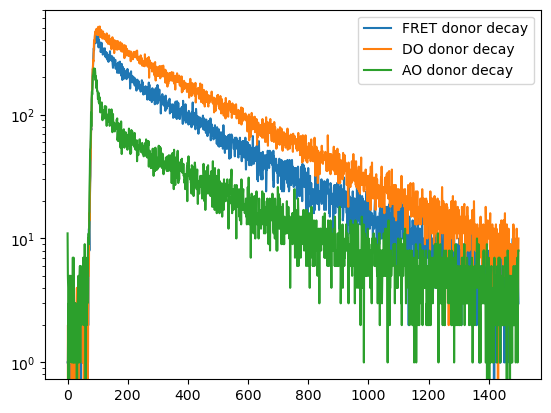

In [53]:
plt.semilogy(data.get_column(nh_fret).sum(axis=0), label='FRET donor decay')
plt.semilogy(data.get_column(nh_DO).sum(axis=0), label='DO donor decay')
plt.semilogy(data.get_column(nh_AO).sum(axis=0), label='AO donor decay')
plt.legend()

### Nanomean Column

What is more comonly analysed is the mean nanotime, which gives you the amplitude weighted lifetime.

Before this is done however, it is necessary to set a threshold based on the position of the IRF.
Because of the short rise at the beginning of the decay due to the IRF, 
photons with nanotimes before the onset of the decay need to be excluded from the computation of the mean nanotime.
Otherwise the nanomean is biased towards too-short lifetimes.

Therefore the `data` object has a special attribute, `data.irf_thresh` 

In [54]:
bursts_fret = bursts.regate(gatec_FRET)
# iterate over all photon selections
for ex in range(2):
    for em in range(2):
        sel = smf.PhSel(f'{ex}ex{em}em')
        # compute histogram
        nhst = data.get_column(smf.Column(bursts_fret, 'nanohist', sel)).sum(axis=0)
        # select max of decay, add shift for excitation range
        data.irf_thresh[sel] = np.argmax(nhst)+data.setup['ex_ranges'][ex][0,0] 

Now that the threshold has been set, we can create `nanomean` columns, where the only key needed is the photon stream.
Note that `nanomean` column generally should only take single stream photon selections.

With this we can compare FRET efficiency and mean nanotime- this is akin to FRET Lines.

(<matplotlib.collections.PathCollection at 0x73f3c9556ff0>,
 Text(0.5, 0, '$\\bar \\tau_{532ex}^{585em}\\: (ns)$'),
 Text(0, 0.5, 'E'))

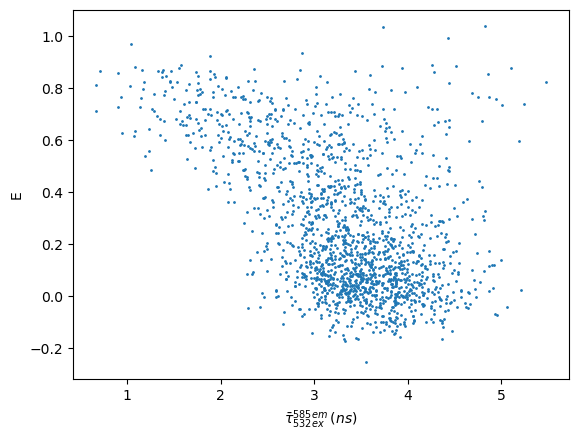

In [55]:
nmDD = smf.Column(bursts.regate(gatec_FRET), 'nanomean', smf.PhSel('0ex0em'))

smf.plot.scatter(data, nmDD, Ec, gate=gatec_FRET, rescale=(-9, 0), s=1.0)

Before starting the apendices, lets remember to get our citations.

In [56]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Müller, B. K., Zaychikov, E., Bräuchle, C. & Lamb, D. C. Pulsed interleaved
    excitation. Biophysical Journal 89, 3508–3522 (2005).
3. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison
    between theory and experiments. Journal of Physical Chemistry B 110,
    22103–22124 (2006).
4. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
5. Hellenkamp, B., Schmid, S., Doroshenko, O. et al. Precision and accuracy of
    single-molecule FRET measurements—a multi-laboratory benchmark study. Nat
    Methods 15, 669–676 (2018).
6. Torella, J. P., Holden, S. J., Santoso, Y., Hohlbein, J. & Kapani

## Apendices

### Description of Correction Matrix

Because smfBurts is designed to handle arbitrary numbers of channels of any type (excitation, emission, polarization, split).
Therefore a generalized and universal form of applying correction factors must be used.

Because arbitrary numbers of channels are used, this means that inventing names for each potential correction factor becomes unweildy,
thus all correction factors are combined into one array (a matrix).

The correction factors are computed as follows

$$ ^{corr}n_{i} = \sum_{j=1}^{N}{M_{i,j}\:^{bg}n_{j}}$$

Where subscript $i$ and $j$ indicate the channel (DexDem, DexAem, AexDem, AexAem, in that order for standard ALEX/PIE measurements), 
and $^{corr}n_{i}$ inidcates the corrected intensity value of said stream, 
and $^{bg}n_{j}$ is the background corrected value of the stream.

It should be noted that for the DexAem stream, tranditional analysis considers the corrected value to be the "FRET" species.

The definitions in [Hellenkamp et. al.](https://doi.org/10.1038/s41592-018-0085-0) render to the following in the matrix representation:

$ \mathbf{M} = \begin{bmatrix}
\gamma & 0 & 0 & 0 \\
-\alpha & 1 & 0 & -\delta \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & \beta
\end{bmatrix}
$

Note that what we have here is matrix multiplication:

$^{corr}n_{i} = \sum_{j=1}^{N}{M_{i,j}\:^{bg}n_{j}} \equiv ^{corr}\vec{n}= \mathbf{M}\:^{bg}\vec{n}$

The index-from-zero numerical index can be computed as follows: 
$N_{ex}N_{pol}N_{split}n_{ex}+N_{pol}N_{split}n_{em}+N_{split}n_{pol}+n_{split}$
where $N$ indicates the number of channels in the given subset, and $n$ is the index from 0 number of the particular stream.
So for a standard ALEX/PIE setup, we have $N_{ex}=2$, $N_{em}=2$, $N_{pol}=1$, and $N_{split}=1$.
And DexDem is $n_{ex} = 0$ and $n_{em}=1$ indicating the 0 index in the matrix (indexing from 0, so index 1 in standard matrix indexing)
while AexAem is $n_{ex} = 0$ and $n_{em}=1$ indicating the 3 index in the matrix.

### Re-deriving correction factors

For a given set of fluorophores, we can describe their intensities in a given channel with the following equation:

$\eta^{f}_{ex|em} = L_{ex}\sigma^{f}_{ex}\phi^{f}g^{f}_{em}$

where $\eta$ is the background corrected intensity $L_{ex}$ is the laser excitation power of the $ex$ laser,
$\sigma^{f}_{ex}$ is the absorbtion coefficient for the fluorophore $f$ at the wavelenth of the $ex$ laser,
$\phi^{f}$ is the quantum yield of the fluorophore $f$,
and $g^{f}_{em}$ is the probability of detecting a photon from the fluorephore $f$ in the emission channel $em$.
\* Note that in [Hellenkamp et. al.](https://doi.org/10.1038/s41592-018-0085-0) $L_{ex}$ was written as $I_{Xex}$,
I have chosen to replace this since the $I$ to avoid confusion with the index $i$ or the identity matrix $\mathbf{I}$..

$g^{f}_{em}$ should be though of as an integral of the detection efficiency and fluorescent spectra of the detector and fluorophore:
$g^{f}_{em} = \int_{0}^{\infty}\rho^{f}(\lambda)\zeta(\lambda)d\lambda$
Where $\rho^{f}$ is the (normalized) fluorescent *emission* spectra of the fluorophore $f$, 
and $\zeta$ is the detection efficiency (accounting for both detector *and* fluorescent filters) used.
If the fluorescent filters were pefect, that is:
$OD(\lambda) = \begin{cases} 1 & low \leq \lambda \leq high \\ 0 & \lambda > high | \lambda < low\end{cases}$
we could re-write this integral with smaller limits:
$g^{f}_{em} = \int_{low}^{high}\rho^{f}(\lambda)\zeta(\lambda)d\lambda$.
In practice of courese this is only approximate, but in most cases it is a reasonable approximation.

Previously all but the $L$ factor have been collected into a cross-section term $\sigma$ ie $L_{ex}\sigma^{f}_{ex|em} = \eta^{f}_{ex|em}$

For each fluorophore there is a distinct $\eta$ value for each unique ex/em combination.

We can therefore construct a matrix with columns of $f$ and rows of $\eta^{f}_{ex|em}$ that converts
concentrations of each species of $f$ into intensities $^{bg}n$ in each channel.

That is:

$^{bg}\vec{n} = \mathbf{C}\:^{corr}\vec{n}$

by which we can see that 

$\mathbf{C}^{-1}\:^{bg}\vec{n} = ^{corr}\vec{n}$

Thus the correction matrix $\mathbf{M} = \mathbf{C}^{-1}$.

For a standard ALEX/PIE measurment, we usually ignore the AexDem channel, and thus the $C$ matrix would look like:

$\mathbf{C} = \begin{bmatrix} 
\eta^{DO}_{Dex|Dem} & \eta^{FRET_{100}}_{Dex|Dem} & \eta^{AO}_{Dex|Dem}\\
\eta^{DO}_{Dex|Aem} & \eta^{FRET_{100}}_{Dex|Aem} & \eta^{AO}_{Dex|Aem}\\
\eta^{DO}_{Aex|Aem} & \eta^{FRET_{100}}_{Aex|Aem} & \eta^{AO}_{Aex|Aem}
\end{bmatrix}$

where $DO$ indicates the donor-only species, $FRET_{100}$ the FRET system where there is 100% fret efficiency, and $AO$ the acceptor only species.

If we suppose a hypothetical "anti-stokes" ($AS$) species, we can complete this matrix for all 4 combinations of excitation/emission as follows:

$\mathbf{M} = \begin{bmatrix} 
\eta^{DO}_{Dex|Dem} & \iota^{FRET_{100}}_{Dex|Dem} & \eta^{DO}_{Dex|Dem} & \eta^{DO}_{Dex|Dem}\\
\eta^{DO}_{Dex|Aem} & \iota^{FRET_{100}}_{Dex|Aem} & \eta^{FRET_{100}}_{Dex|Aem} & \eta^{FRET_{100}}_{Dex|Aem}\\
\eta^{DO}_{Aex|Dem} & \iota^{FRET_{100}}_{Aex|Dem} & \eta^{AS}_{Aex|Dem} & \eta^{AS}_{Aex|Dem}\\
\eta^{DO}_{Aex|Aem} & \iota^{FRET_{100}}_{Aex|Aem} & \eta^{AO}_{Aex|Aem} & \eta^{AO}_{Aex|Aem}
\end{bmatrix}$

Now, let's replace the elements of this matrix with 0's where we expect value of $\eta^{f}_{ex|em}$ to be 0:

$\mathbf{C} = 
\begin{bmatrix} 
\eta^{DO}_{Dex|Dem} & 0 & 0 & 0\\
\eta^{DO}_{Dex|Aem} & \eta^{FRET_{100}}_{Dex|Aem} & 0 & \eta^{AO}_{Aex|Aem}\\
0 & 0 & \eta^{AS}_{Aex|Dem} & 0\\
0 & 0 & 0 & \eta^{AO}_{Aex|Aem}
\end{bmatrix}$

Now, if we set $\eta^{FRET_{100}}_{Dex|Aem} = 1$, we can replace $\eta^{DO}_{Dex|Aem}$ with $\alpha$ as 

We can solve for the inverse:


$\begin{bmatrix}
{\eta^{DO}_{Dex|Dem}}^{-1} & 0 & 0 & 0 \\
(-\eta^{DO}_{Dex|Aem}{\eta^{DO}_{Dex|Dem}}^{-1}{\eta^{FRET_{100}}_{Dex|Aem}}^{-1}) & {\eta^{FRET_{100}}_{Dex|Aem}}^{-1} & 0 & (-\eta^{AO}_{DexAem}{\eta^{FRET_{100}}_{Dex|Aem}}^{-1}{\eta^{AO}_{Aex|Aem}}^{-1}) \\
0 & 0 & {\eta^{AS}_{Aex|Dem}}^{-1} & 0 \\
0 & 0 & 0 & {\eta^{AO}_{Aex|Aem}}^{-1}
\end{bmatrix}$

So 

$\mathbf{C}^{-1} = 
\begin{bmatrix}
{\eta^{DO}_{Dex|Dem}}^{-1} & 0 & 0 & 0 \\
(-\eta^{DO}_{Dex|Aem}{\eta^{DO}_{Dex|Dem}}^{-1}{\eta^{FRET_{100}}_{Dex|Aem}}^{-1}) & {\eta^{FRET_{100}}_{Dex|Aem}}^{-1} & 0 & (-\eta^{AO}_{DexAem}{\eta^{FRET_{100}}_{Dex|Aem}}^{-1}{\eta^{AO}_{Aex|Aem}}^{-1}) \\
0 & 0 & {\eta^{AS}_{Aex|Dem}}^{-1} & 0 \\
0 & 0 & 0 & {\eta^{AO}_{Aex|Aem}}^{-1}
\end{bmatrix}$

Now if we define $\eta^{FRET_{100}}_{Dex|Aem} \equiv 1$
we can simplify:

$\mathbf{C}^{-1} = 
\begin{bmatrix}
{\eta^{DO}_{Dex|Dem}}^{-1} & 0 & 0 & 0 \\
(-\eta^{DO}_{Dex|Aem}{\eta^{DO}_{Dex|Dem}}^{-1}) & 1 & 0 & (-\eta^{AO}_{DexAem}{\eta^{AO}_{Aex|Aem}}^{-1}) \\
0 & 0 & {\eta^{AS}_{Aex|Dem}}^{-1} & 0 \\
0 & 0 & 0 & {\eta^{AO}_{Aex|Aem}}^{-1}
\end{bmatrix}$

Note that the $L$, $\sigma$ and $\phi$ terms in $\eta^{DO}_{Dex|Aem}{\eta^{DO}_{Dex|Dem}}^{-1}$ cancel out (these are "excitation" related terms):

$\eta^{DO}_{Dex|Aem}{\eta^{DO}_{Dex|Dem}}^{-1} = 
\frac{L_{Dex}\sigma^{DO}_{Dex}\phi^{DO}g^{DO}_{Dem}}{L_{Dex}\sigma^{DO}_{Dex}\phi^{DO}g^{DO}_{Aem}} =
\frac{g^{DO}_{Aem}}{g^{DO}_{Dem}} \equiv \alpha$

and that in a similar way the terms $g$ and $\phi$ terms in $\eta^{AO}_{Dex|Aem}{\eta^{AO}_{Aex|Aem}}^{-1}$ cancel out (these are "detection" related terms):

$\eta^{AO}_{Dex|Aem}{\eta^{AO}_{Aex|Aem}}^{-1} = 
\frac{L_{Dex}\sigma^{AO}_{Dex}\phi^{AO}g^{AO}_{Aem}}{L_{Aex}\sigma^{AO}_{Aex}\phi^{AO}g^{AO}_{Aem}} = 
\frac{L_{Dex}\sigma^{AO}_{Dex}}{L_{Aex}\sigma^{AO}_{Aex}} \equiv \delta$

Also, using the identity $1 \equiv \eta^{FRET_{100}}_{Aem} = L_{Dex}\sigma^{FRET_{100}}_{Dex}\phi^{FRET_{100}}g^{FRET_{100}}_{Aem}$ 
and assuming that $\sigma^{FRET_{100}}_{Dex} = \sigma^{DO}_{Dex}$, we can show that:

${\eta^{DO}_{Dex|Aem}}^{-1} = 
\frac{1}{L_{Dex}\sigma^{DO}_{Dex}\phi^{DO}g^{DO}_{Aem}} = 
\frac{L_{Dex}\sigma^{FRET_{100}}_{Dex}\phi^{FRET_{100}}g^{FRET_{100}}_{Aem}}{L_{Dex}\sigma^{DO}_{Dex}\phi^{DO}g^{DO}_{Aem}} = 
\frac{\phi^{FRET_{100}}g^{FRET_{100}}_{Aem}}{\phi^{DO}g^{DO}_{Aem}} \equiv \gamma$

and using the same identiy and assuming that $\phi^{FRET_{100}} = \phi^{AO}$ and $g^{FRET_{100}}_{Aem} = g^{AO}_{Aem}$, we can show that:

${\eta^{AO}_{Aex|Aem}}^{-1} = 
\frac{1}{L_{Aex}\sigma^{AO}_{Aex}\phi^{AO}g^{AO}_{Aem}} = 
\frac{L_{Dex}\sigma^{FRET_{100}}_{Dex}\phi^{FRET_{100}}g^{FRET_{100}}_{Aem}}{L_{Aex}\sigma^{AO}_{Aex}\phi^{AO}g^{AO}_{Aem}} = 
\frac{L_{Dex}\sigma^{FRET_{100}}_{Dex}}{L_{Aex}\sigma^{AO}_{Aem}} \equiv \beta^{-1}$


Thus, subsituting the identities, and also assigning $1 \equiv \eta^{AS}_{Aex|Dem}$ into the matrix, we show that the result is the same as the original derivation of correction factors:

$\mathbf{C}^{-1} = 
\begin{bmatrix}
\gamma & 0 & 0 & 0 \\
-\alpha & 1 & 0 & -\delta \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & \beta^{-1}
\end{bmatrix}$

One can anticipte however that poorer filters/overlapping dyes etc could result in cross-talk between channels that, in the classic smFRET formulation are 0.
In such cases, isolating 1 species per channel, and implementing an inverse matrix of each species set of $\eta$ values,
will produce a correction matrix with more non-zero terms, and produce a much more accurate final result.

In [57]:
r = smf.Param(smf.Ratios, 
              params={'corr_mat':np.array([[ gamma, 0.0, 0.0,     0.0],
                                           [-alpha, 1.0, 0.0,  -delta],
                                           [  0.0, 0.0, 1.0,      0.0],
                                           [  0.0, 0.0, 0.0, 1.0/beta]])},
              parents={'nph':nphbg})

## Full Column List

Column         | key tuple             | description                                                                                     
---------------|---------------------|---------------------------------------------------------------------------------------------------
start          | ()                  | start time (inclusive, in `PhotonData` clocks) in time range
stop           | ()                  | stop time (exclusive, in `PhotonData` clocks) in time range
istart         | ()                  | number (index) of first photon in time range
istop          | ()                  | number (index) first photon after end of time range (last photon + 1)
istarttime     | ()                  | time of first photon in time range (in `PhotonData` clocks) inclusive
istoptime      | ()                  | time of last photon in time range (in `PhotonData` clocks) *inclusive*
midtime        | (str\*, str\*)      | midpoint between start and stop times defined by two srings
ph_mask        | (PhSel, )           | boolean mask for photons in time range, `True` for photons in PhSel
ph_times       | (PhSel, )           | arrival times (in `PhotonData` clocks) of each photon in PhSel in time range
ph_nanos       | (PhSel, )           | nanotimes times (in tcspc clocks) of each photon in PhSel in time range
ph_dets        | (PhSel, )           | detector indecies (normalized) of each photon in PhSel in time range
ph_particles   | (PhSel, )           | detector indecies (normalized) of each photon in PhSel in time range
nph_raw        | (PhSel, )           | number of photons (raw counts, no bg subtraction) in PhSel in time range
ratio_raw      | (PhSel, PhSel)      | ratio of number of photons in first stream to second (no bg correction)
anisotropy_raw | (PhSel, PhSel)      | Computes anisotropy between first and second PhSel, with first as parallel, only useful when using MFD
E_raw          | ()                  | Raw FRET efficiency- this is a shortcut for `["ratio_raw", smf.PhSel("0ex1em"), smf.PhSel("0ex")]`
S_raw          | ()                  | Raw Stoichiometry- this is a shortcut for `["ratio_raw", smf.PhSel("0ex"), smf.PhSel("0ex_1ex1em")]`
max_rate       | (PhSel, int)        | maximum photon range (in $cnts\:s^{-1}$) of PhSel in time range using sliding window of size int
meanT          | (PhSel, )           | mean time of the stream in PhSel
mTdiff         | (PhSel, PhSel)      | difference in time (in seconds) between mean of first and second  PhSel arrival times
bva            | (PhSel, PhSel, int) | burst variance analysis, using ratio of 2 PhSells, and chuck size of int
dur            | (str, str)          | Duration of time range, first str defines start time, second stop time
brightness     | (PhSel, str, str)   | brightness (in $cnt\:s^{-1}$ no bg adjustment) of time range for PhSel, range defined as in dur\*
nanohist       | (PhSel, )           | nanotime histogram of all photons in PhSel in time range
nanomean       | (PhSel, )           | mean nanotime (in seconds) of photons in PhSel with nantime greater than thresh for stream

## All Gate Operations

Gates support a variety of logical operations.


> **Note**
>
> The `~` operator is a main reason why the `smf.make_geq_gate()` and `smf.make_lt_gate()` functions produce gates that do not include the gate of the input `Column`.
>
> If these functions produced gates that incldued the gate of the input `Column`, the the `~` operator would negate those initial gates as well.

Operator         | Description
-----------------|------------
`A&B` or `A*B`   | and - true only where A and B are true
`A\|B` or `A&B`  | or - true if A or B or both are true
`A-B`            | subtract - true only where A is true and B is false (equivalent to `(A\|B)&~B`)
`A@B`            | equal - True where both gates are true or both gates are false
`A^B`            | not equal/xor - True where one gate is false and the other is true
`A>>B`           | implies - True if A is false or both are true
`A<<B`           | reverse implies - True if B is false or both are true

(-0.2, 1.2)

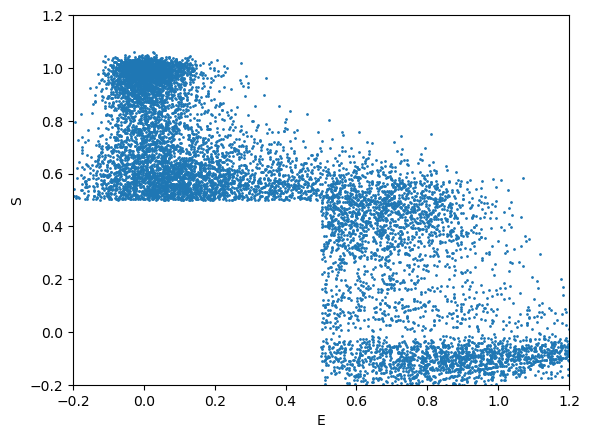

In [58]:
# demonstration of | operation on gates
gate_or = smf.make_geq_gate(Ec, 0.5) | smf.make_geq_gate(Sc, 0.5)
gateAll_or = gateAll & gate_or

Eor = Ec.regate(gateAll_or)
Sor = Sc.regate(gateAll_or)

smf.plot.scatter(data, Eor, Sor, s=1.0)
plt.xlim([-0.2, 1.2])
plt.ylim([-0.2, 1.2])

(-0.2, 1.2)

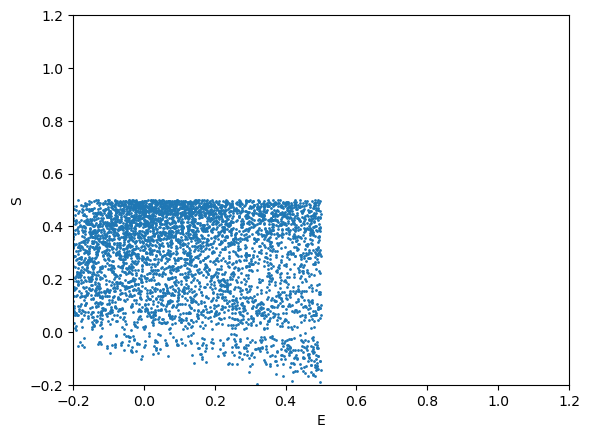

In [59]:
# demonstrating the ~ opeartion
gate_orI = ~gate_or
gateAll_orI = gateAll & gate_orI

EorI = Ec.regate(gateAll_orI)
SorI = Sc.regate(gateAll_orI)

smf.plot.scatter(data, EorI, SorI, s=1.0)
plt.xlim([-0.2, 1.2])
plt.ylim([-0.2, 1.2])

In [ ]:
# Demonstrating teh ^ operation
gate_a = smf.make_geq_gate(Sc, 0.5) & smf.make_geq_gate(Ec, 0.2)
gate_b = smf.make_lt_gate(Sc, 0.5) & smf.make_lt_gate(Ec, 0.2)
gate_xor = gate_a ^ gate_b
gateAll_xor = gateAll & gate_xor
gateAll_nxor = gateAll & ~gate_xor

smf.plot.scatter(data, Ec, Sc, gate=gateAll_xor, s=1.0)
smf.plot.scatter(data, Ec, Sc, gate=gateAll_nxor, s=1.0)
plt.xlim([-0.2, 1.2])
plt.ylim([-0.2, 1.2])

Thus concludes Understanding gates.